# Higgs Boson Event Detection: Capstone Project


### Contents

- [**1. Introduction**](#1.-Introduction)
- [**2. Objective and Problem Statement**](#2.-Objective-and-Problem-Statement)
- [**3. Data Loading, Setup and Dataset Description**](#3.-Data-Loading-,-Setup-and-Dataset-Description)
- [**4. Exploratory Data Analysis (EDA)**](#4.-Exploratory-Data-Analysis-(EDA))
- [**5. Data Preprocessing**](#5.-Data-Preprocessing)
- [**6. Feature Engineering**](#6.-Feature-Engineering)
- [**7. Model Building**](#7.-Model-Building)
- [**8. Evaluation Metrics and Validation**](#8.-Evaluation-Metrics-and-Validation)
- [**9. Feature Importance**](#9.-Feature-Importance)
- [**10. Predictions on Test Set**](#10.-Predictions-on-Test-Set)
- [**11. Key Insights**](#11.-Key-Insights)
- [**12. Conclusion**](#12.-Conclusion)
- [**13. References**](#13.-References)



## 1. Introduction

In particle physics, events refer to the results just after a fundamental interaction took place between subatomic particles, occurring in a very short time span in a well-localized region of space. A background event is explained by the existing theories. On the other hand, a signal event indicates a process that cannot be described by previous observations and leads to the potential discovery of a new particle. In this project, we aim to predict if a given event is background or signal.

## 2. Objective and Problem Statement
**The objective of the project is to classify an event produced in the particle accelerator as background or signal**. As described earlier, a **background event** is explained by the existing theories and previous observations. A **signal event**, however, indicates a process that cannot be described by previous observations and leads to the potential discovery of a new particle.

## Problem Statement

- **Goal:** Predict whether a particle collision event is a “signal” (Higgs boson) or just background noise.
- **Why it matters:** Finding the Higgs boson is like finding a needle in a haystack, and machine learning helps us find that needle faster and more accurately.


## 3. Data Loading, Setup and Dataset Description




The dataset has been built from official ATLAS full-detector simulation. The simulator has two parts. In the first, random proton-proton collisions are simulated. It reproduces the random microscopic explosions resulting from the proton-proton collisions.

In the second part, the resulting particles are tracked through a virtual model of the detector. The process yields simulated events with properties that mimic the statistical properties of the real events with additional information on what has happened during the collision, before particles are measured in the detector.

**Signal sample and background sample.** The signal sample contains events in which Higgs bosons (with a fixed mass of $125$ [**GeV**]) were produced. The background sample was generated by other known processes that can produce events with at least one electron or muon and a hadronic tau, mimicking the signal. Only three background processes were retained for the dataset. The first comes from the decay of the $Z$ boson (with a mass of $91.2$ GeV) into two taus. This decay produces events with a topology very similar to that produced by the decay of a Higgs. The second set contains events with a pair of top quarks, which can have a lepton and a hadronic tau among their decay. The third set involves the decay of the $W$ boson, where one electron or muon and a hadronic tau can appear simultaneously only through imperfections of the particle identification procedure.

In [ ]:
# Installing CatBoost
!pip install catboost --quiet

In [ ]:
# Importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Mounting Google Drive to access the files there
from google.colab import drive

# Allows all permissions to access the content of my google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Setting the directory path as the environment of Kaggle Confing Directory
import os

# Setting environ to the directory where kaggle.json is stored
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive' # from files get the path

In [ ]:
# Downloads a zip file containing the competition data to the current directory in the Colab environment.
!kaggle competitions download -c higgs-boson

higgs-boson.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Unzip the zip file of dataset into the dataset folder
!unzip /content/higgs-boson.zip

Archive:  /content/higgs-boson.zip
replace HiggsBosonCompetition_AMSMetric_rev1.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# Load the data
train = pd.read_csv('/content/training.zip')
test = pd.read_csv('/content/test.zip')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (250000, 33)
Test shape: (550000, 31)


We start by loading the data. Each row is a particle collision event, with measurements (features) and a label: “s” for signal (Higgs boson) or “b” for background (not Higgs).

**Training set and test set.** The training set and the test set respectively contains $250000$ and $550000$ observations. The two sets share $31$ common features between them. Additionally, the training set contains **labels** (**signal** or **background**) and **weights**.

## 4. Exploratory Data Analysis (EDA)

### 4.1 What does the data look like?

###  **Target**

* **Label**: Indicates whether the event is a **signal** (s = likely Higgs boson) or **background** (b = non-Higgs event).
* **Weight**: Importance of each event for the evaluation metric (used for calculating the AMS score in the challenge).

---

###  **Event Information**

* **EventId**: A unique identifier for each event. Not useful as a feature but helpful for tracking predictions.

---

###  **Primary (Raw) Features (PRI\_\*)**

These are the original, unprocessed measurements from the detector:

1. **PRI\_tau\_pt, PRI\_tau\_eta, PRI\_tau\_phi**: Tau lepton's transverse momentum, pseudorapidity, and azimuthal angle.
2. **PRI\_lep\_pt, PRI\_lep\_eta, PRI\_lep\_phi**: Same for the lepton (either electron or muon).
3. **PRI\_met**: Magnitude of missing transverse energy (MET) — from undetected particles like neutrinos.
4. **PRI\_met\_phi**: Direction (azimuthal angle) of the MET.
5. **PRI\_met\_sumet**: Scalar sum of transverse energies in the event.
6. **PRI\_jet\_num**: Number of jets detected (0–3 or more).
7. **PRI\_jet\_leading\_pt, PRI\_jet\_leading\_eta, PRI\_jet\_leading\_phi**: Properties of the most energetic (leading) jet.
8. **PRI\_jet\_subleading\_pt, PRI\_jet\_subleading\_eta, PRI\_jet\_subleading\_phi**: Properties of the second most energetic jet.
9. **PRI\_jet\_all\_pt**: Scalar sum of all jets' transverse momenta.


---

###  **Derived Features (DER\_\*)**

These features are calculated (i.e., *derived*) from the raw measurements using physics formulas and relationships:

1. **DER\_mass\_MMC**: Mass calculated using the Missing Mass Calculator (MMC). It's an estimate of the invariant mass of the Higgs boson. Very important.
2. **DER\_mass\_transverse\_met\_lep**: Transverse mass between MET and lepton — useful for identifying signal characteristics.
3. **DER\_mass\_vis**: Visible mass from the tau and the lepton. Only includes detected particles.
4. **DER\_pt\_h**: Transverse momentum of the Higgs candidate.
5. **DER\_deltaeta\_jet\_jet**: Difference in pseudorapidity (η) between the two jets. High values can signal background.
6. **DER\_mass\_jet\_jet**: Invariant mass of the two leading jets.
7. **DER\_prodeta\_jet\_jet**: Product of pseudorapidities of the two jets — used in VBF (Vector Boson Fusion) analysis.
8. **DER\_deltar\_tau\_lep**: Distance between tau and lepton in the η–φ plane (ΔR). Good discriminator.
9. **DER\_pt\_tot**: Total transverse momentum in the event.
10. **DER\_sum\_pt**: Scalar sum of the transverse momenta of all visible particles.
11. **DER\_pt\_ratio\_lep\_tau**: Ratio of transverse momenta between lepton and tau.
12. **DER\_met\_phi\_centrality**: Centrality of missing energy w\.r.t. visible particles.
13. **DER\_lep\_eta\_centrality**: Centrality of lepton η w\.r.t. the jets.

---

In [ ]:
train.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


Here are the first few rows. Each column is a measurement from the experiment. The “Label” column is what we want to predict.



In [ ]:
# Count of observations
df_obs = pd.DataFrame(index = ['Number of observations'], columns = ['Training set', 'Test set'])
df_obs['Training set'] = len(train)
df_obs['Test set'] = len(test)
df_obs

,Training set,Test set
Number of observations,250000,550000


In [ ]:
# Count of columns
df_cols_count = pd.DataFrame(index = ['Number of columns'], columns = ['Training set', 'Test set'])
df_cols_count['Training set'] = len(train.columns)
df_cols_count['Test set'] = len(test.columns)
df_cols_count

,Training set,Test set
Number of columns,33,31


In [ ]:
# Column names for the training dataset
train.columns

Index(['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt',
       'Weight', 'Label'],
      dtype='object')

In [ ]:
# Column names for the test dataset
test.columns

Index(['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep',
       'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
       'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt',
       'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality',
       'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi',
       'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi',
       'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt',
       'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt',
       'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt'],
      dtype='object')

In [ ]:
# Columns in the training dataset which are not in the test dataset
[col for col in train.columns if col not in test.columns]

['Weight', 'Label']

In [ ]:
# Column datatypes for the training dataset
train.dtypes

,0
EventId,int64
DER_mass_MMC,float64
DER_mass_transverse_met_lep,float64
DER_mass_vis,float64
DER_pt_h,float64
DER_deltaeta_jet_jet,float64
DER_mass_jet_jet,float64
DER_prodeta_jet_jet,float64
DER_deltar_tau_lep,float64
DER_pt_tot,float64


The columns of the test set are exactly the first $31$ columns of the training set, i.e. all columns except Weight and Label. The datatypes of these columns are already reported above, for the training set. So we are not repeating it again for the test set.


In [ ]:
# Integer columns in the training dataset
train.columns[train.dtypes == 'int64']

Index(['EventId', 'PRI_jet_num'], dtype='object')

In [ ]:
# Object columns in the training dataset
train.columns[train.dtypes == 'object']

Index(['Label'], dtype='object')

In [ ]:
# Count of column datatypes for the test dataset
df_cols_test = pd.DataFrame(index = ['Number of columns for the test set'], columns = ['Integer', 'Float', 'Object'])
df_cols_test['Integer'] = len(test.columns[test.dtypes == 'int64'])
df_cols_test['Float'] = len(test.columns[test.dtypes == 'float64'])
df_cols_test['Object'] = len(test.columns[test.dtypes == 'object'])
df_cols_test

,Integer,Float,Object
Number of columns for the test set,2,29,0


In [ ]:
# Count of duplicate rows
df_duplicate_rows = pd.DataFrame(index = ['Number of duplicate rows'], columns = ['Training set', 'Test set'])
df_duplicate_rows['Training set'] = train.duplicated().sum()
df_duplicate_rows['Test set'] = test.duplicated().sum()
df_duplicate_rows

,Training set,Test set
Number of duplicate rows,0,0


In [ ]:
# Constant columns in the training set
cols_constant_train = train.columns[train.nunique() == 1].tolist()
if len(cols_constant_train) == 0:
    cols_constant_train = "None"
print(pd.Series({"Constant columns in the training set": cols_constant_train}).to_string())

Constant columns in the training set    None


In [ ]:
# Constant columns in the test set
cols_constant_test = test.columns[test.nunique() == 1].tolist()
if len(cols_constant_test) == 0:
    cols_constant_test = "None"
print(pd.Series({"Constant columns in the test set": cols_constant_test}).to_string())

Constant columns in the test set    None


### 4.2 Are the classes balanced?

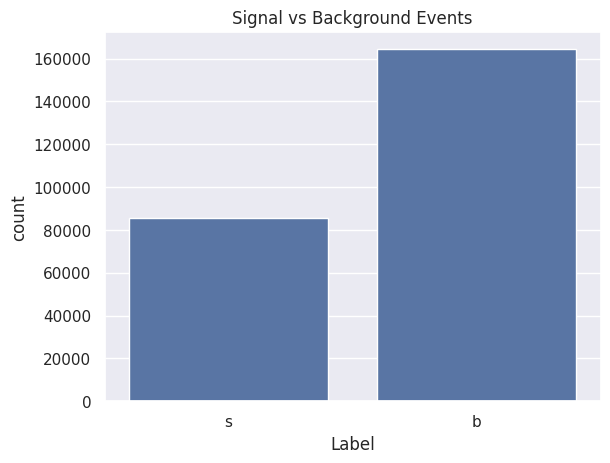

In [ ]:
sns.countplot(x='Label', data=train)
plt.title('Signal vs Background Events')
plt.show()

The plot shows how many events are “signal” (s) and how many are “background” (b).

**Key Insight:**  
There are more background events than signal events. This means our model needs to be careful not to just guess “background” all the time.



### 4.3 Are there missing values?

In [ ]:
# Count of columns with missing values
df_missing = pd.DataFrame(index = ['Number of columns with missing values'], columns = ['Training set', 'Test set'])
df_missing['Training set'] = len(train.isna().sum()[train.isna().sum() != 0])
df_missing['Test set'] = len(test.isna().sum()[test.isna().sum() != 0])
df_missing

,Training set,Test set
Number of columns with missing values,0,0


In [ ]:
missing = (train == -999.0).sum()
missing[missing > 0].sort_values(ascending=False)

,0
DER_deltaeta_jet_jet,177457
DER_mass_jet_jet,177457
DER_prodeta_jet_jet,177457
PRI_jet_subleading_phi,177457
DER_lep_eta_centrality,177457
PRI_jet_subleading_eta,177457
PRI_jet_subleading_pt,177457
PRI_jet_leading_eta,99913
PRI_jet_leading_pt,99913
PRI_jet_leading_phi,99913


Some features use -999.0 to mean “missing data”. We’ll need to handle these missing values before modeling.



In [ ]:
# Statistical description of numerical variables in the training set
train.describe()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,224999.500000,-49.023079,49.239819,81.181982,57.895962,-708.420675,-601.237051,-709.356603,2.373100,18.917332,...,209.797178,0.979176,-348.329567,-399.254314,-399.259788,-692.381204,-709.121609,-709.118631,73.064591,1.646767
std,72168.927986,406.345647,35.344886,40.828691,63.655682,454.480565,657.972302,453.019877,0.782911,22.273494,...,126.499506,0.977426,532.962789,489.338286,489.333883,479.875496,453.384624,453.389017,98.015662,1.875103
min,100000.000000,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,...,13.678000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000,0.001502
25%,162499.750000,78.100750,19.241000,59.388750,14.068750,-999.000000,-999.000000,-999.000000,1.810000,2.841000,...,123.017500,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000,0.018636
50%,224999.500000,105.012000,46.524000,73.752000,38.467500,-999.000000,-999.000000,-999.000000,2.491500,12.315500,...,179.739000,1.000000,38.960000,-1.872000,-2.093000,-999.000000,-999.000000,-999.000000,40.512500,1.156188
75%,287499.250000,130.606250,73.598000,92.259000,79.169000,0.490000,83.446000,-4.593000,2.961000,27.591000,...,263.379250,2.000000,75.349000,0.433000,0.503000,33.703000,-2.457000,-2.275000,109.933750,2.404128
max,349999.000000,1192.026000,690.075000,1349.351000,2834.999000,8.503000,4974.979000,16.690000,5.684000,2834.999000,...,2003.976000,3.000000,1120.573000,4.499000,3.141000,721.456000,4.500000,3.142000,1633.433000,7.822543


In [ ]:
# Statistical description of categorical variables in the training set
train.describe(include = ['O'])

,Label
count,250000
unique,2
top,b
freq,164333


In [ ]:
# Statistical description of numerical variables in the test set
test.describe()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
count,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,...,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000,550000.000000
mean,624999.500000,-48.950144,49.261093,81.123904,57.824801,-707.448878,-599.705905,-708.391425,2.374076,18.988277,...,-0.008214,209.933695,0.980171,-348.946684,-399.883839,-399.896234,-691.309277,-708.150605,-708.153058,73.248856
std,158771.468364,406.233686,35.425422,40.435560,63.291314,454.928791,659.129589,453.461222,0.779895,21.767376,...,1.812777,126.910079,0.979271,533.155176,489.467786,489.457747,480.435230,453.834190,453.830095,98.467134
min,350000.000000,-999.000000,0.000000,6.810000,0.000000,-999.000000,-999.000000,-999.000000,0.237000,0.000000,...,-3.142000,13.847000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000
25%,487499.750000,78.167750,19.313000,59.422000,14.192000,-999.000000,-999.000000,-999.000000,1.815000,2.838000,...,-1.574000,122.984750,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000
50%,624999.500000,105.076000,46.455500,73.747000,38.469500,-999.000000,-999.000000,-999.000000,2.492000,12.390000,...,-0.017000,179.949000,1.000000,38.970000,-1.862000,-2.111000,-999.000000,-999.000000,-999.000000,40.503500
75%,762499.250000,130.769000,73.646000,92.173000,79.234250,0.503000,84.266250,-4.538000,2.962000,27.649000,...,1.558000,263.917250,2.000000,75.499000,0.431000,0.484000,33.832000,-2.429000,-2.260000,110.507000
max,899999.000000,1949.261000,968.669000,1264.965000,1337.187000,8.724000,4794.827000,17.294000,5.751000,759.363000,...,3.142000,2190.275000,3.000000,1163.439000,4.500000,3.142000,817.801000,4.500000,3.142000,1860.175000


**Training set synopsis:**

- Number of observations: $250000$
- Number of columns: $33$
- Number of integer columns: $2$
- Number of float columns: $30$
- Number of object columns: $1$
- Number of duplicate observations: $0$
- Constant columns: None
- Number of columns with missing values: $0$
- Memory Usage: $62.94$ MB

**Test set synopsis:**

- Number of observations: $550000$
- Number of columns: $31$
- Number of integer columns: $2$
- Number of float columns: $29$
- Number of object columns: $0$
- Number of duplicate observations: $0$
- Constant columns: None
- Number of columns with missing values: $0$
- Memory Usage: $130.08$ MB

### 4.4 What do the features look like?

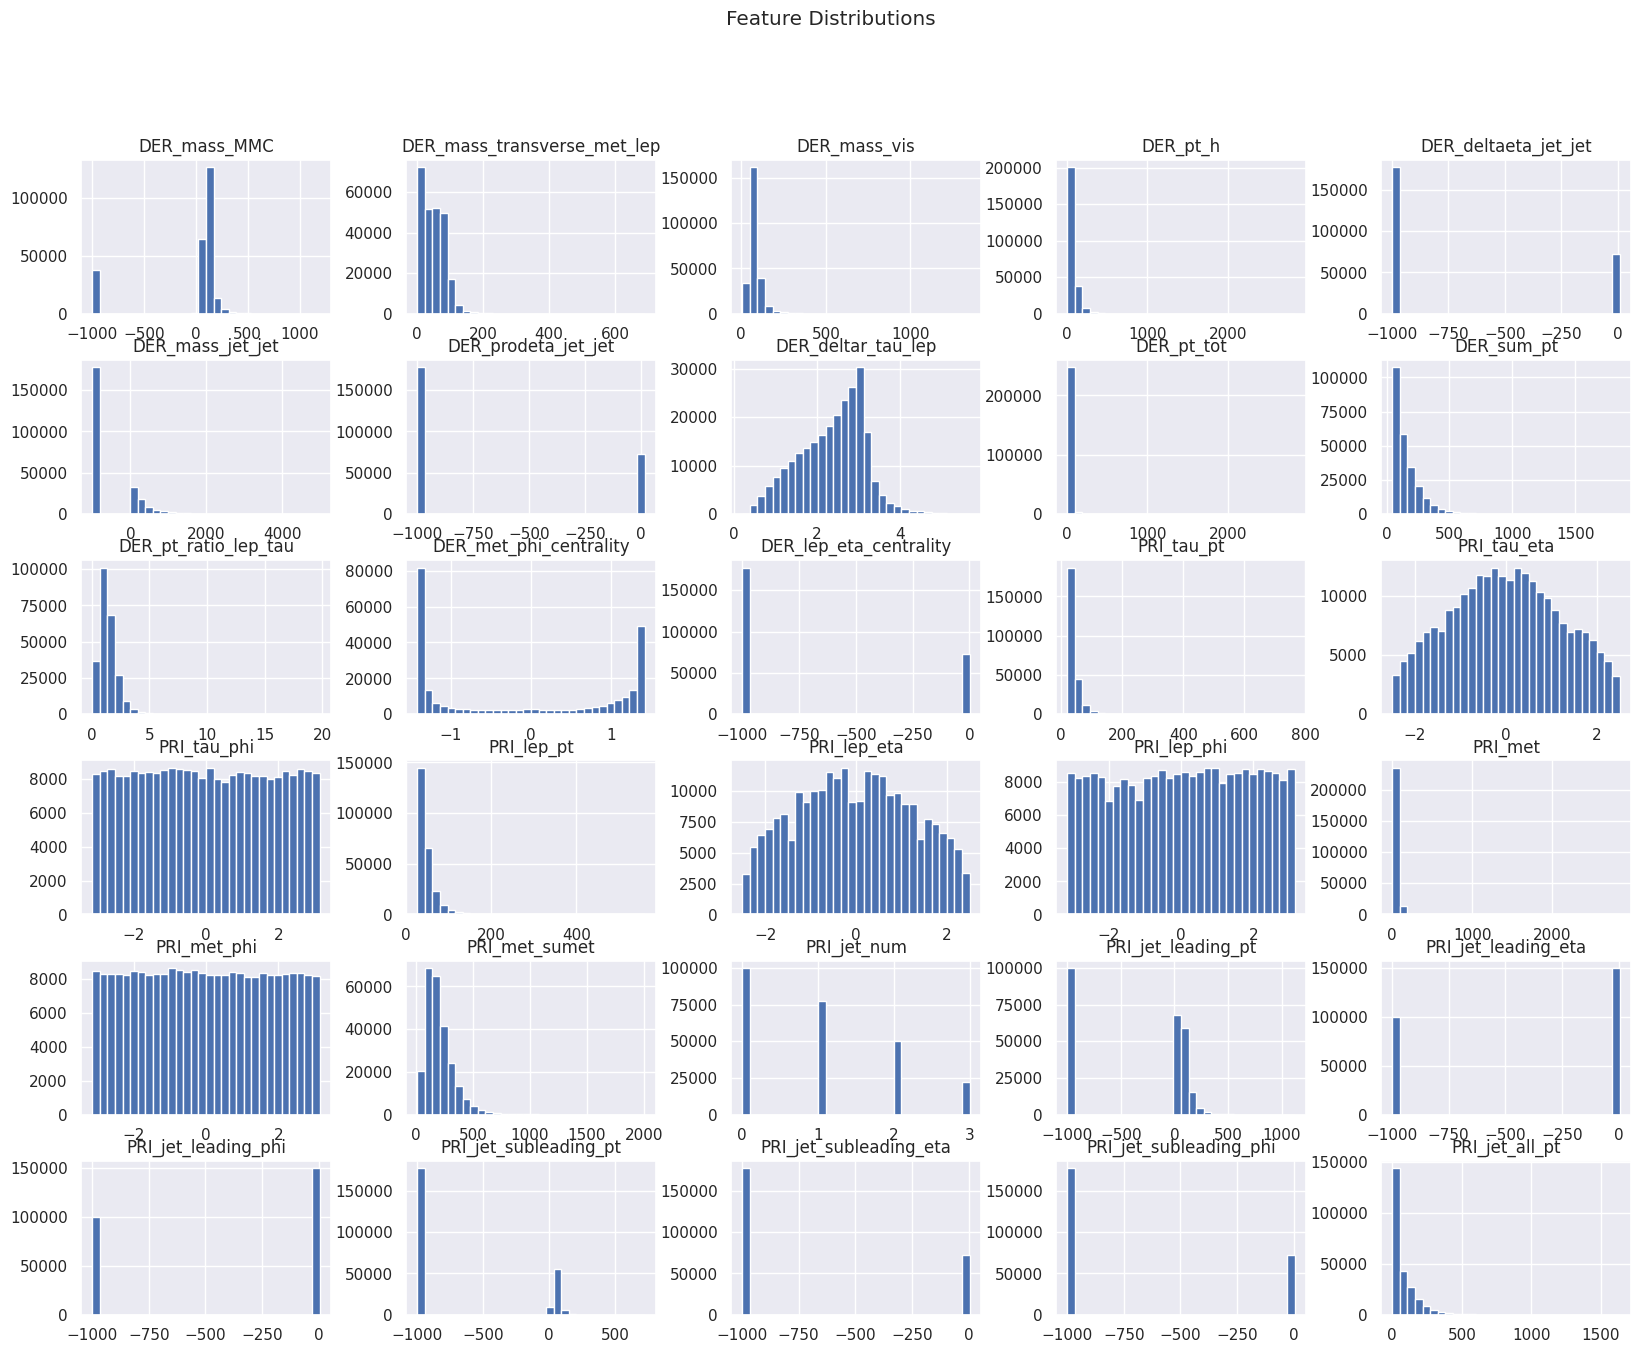

In [ ]:
features = [col for col in train.columns if col not in ['EventId', 'Label', 'Weight']]
train[features].hist(figsize=(20, 15), bins=30)
plt.suptitle('Feature Distributions')
plt.show()

  
This shows how each measurement is distributed. Some are spread out, some are clustered. This helps us understand the data.


**Target Variable**

The target `Label` is a binary variable, taking values `b` and `s`, indicating the status of an event.
\begin{align*}
&\text{b} \,\,\mapsto \text{background event}\\
&\text{s} \,\,\mapsto \text{signal event}
\end{align*}

In [ ]:
# Function to construct barplot and donutplot of a dataframe column
def bar_donut(df, col, h = 500, w = 800):
    fig = make_subplots(rows = 1, cols = 2, specs = [[{'type': 'xy'}, {'type': 'domain'}]])
    x_val, y_val = df[col].value_counts(sort = False).index.tolist(), df[col].value_counts(sort = False).tolist()
    fig.add_trace(go.Bar(x = x_val, y = y_val, text = y_val, textposition = 'auto'), row = 1, col = 1)
    fig.add_trace(go.Pie(values = y_val, labels = x_val, hole = 0.5, textinfo = 'label+percent', title = f"{col}"), row = 1, col = 2)
    fig.update_layout(height = h, width = w, showlegend = False, xaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1), title = dict(text = f"Frequency distribution of {col}", x = 0.5, y = 0.95))
    fig.show()

In [ ]:
# Target variable
bar_donut(train, 'Label')

These plots show how some measurements are different for signal and background. Features where the curves are different are helpful for our model.




### 4.5 How are features related?

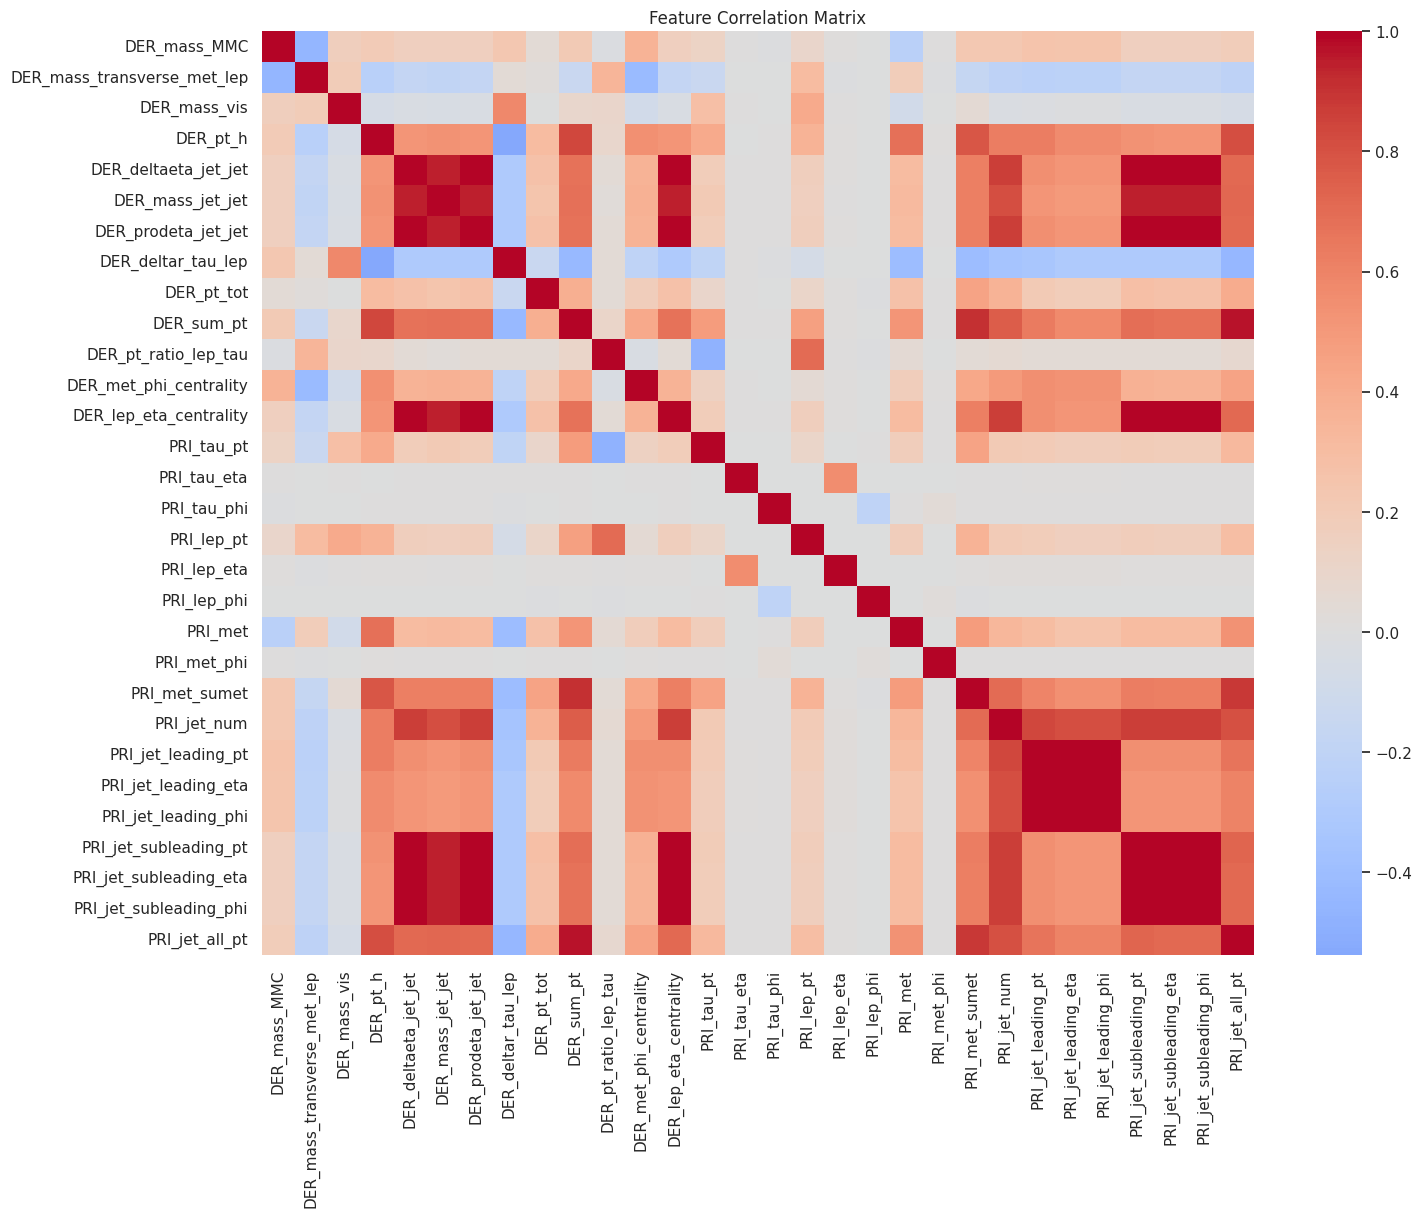

In [ ]:
corr = train[features].corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

This heatmap shows which features are related. If two features are highly related, we might not need both.



### 4.6 How do signals and background differ?

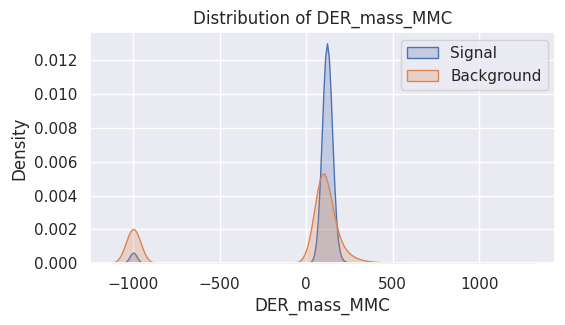

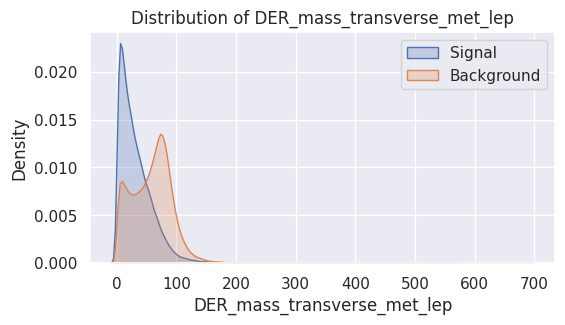

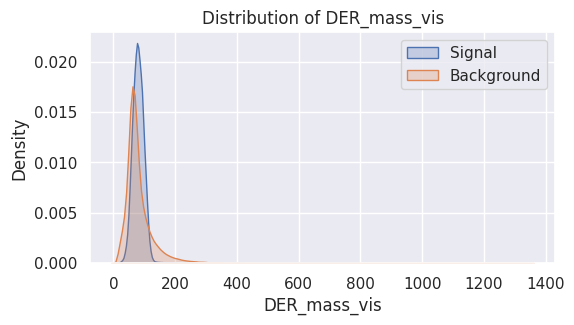

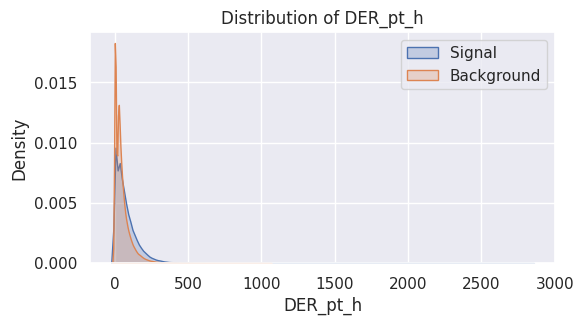

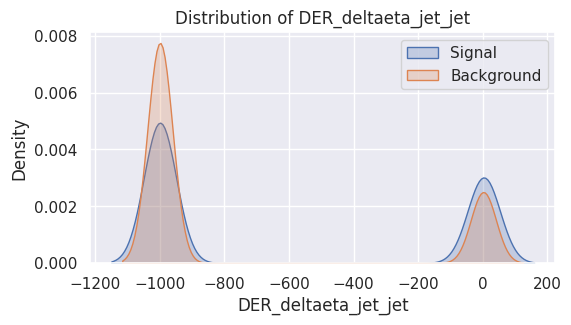

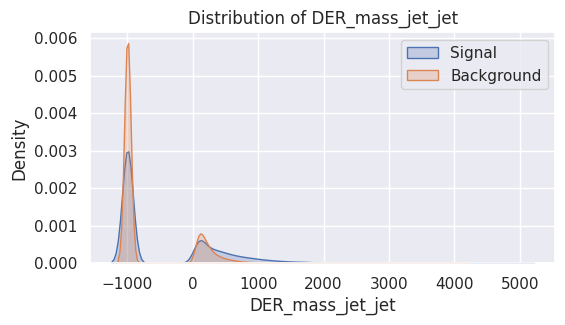

In [ ]:
signal = train[train['Label'] == 's']
background = train[train['Label'] == 'b']

for f in features[:6]:  # Show a few for clarity
    plt.figure(figsize=(6,3))
    sns.kdeplot(signal[f], label='Signal', shade=True)
    sns.kdeplot(background[f], label='Background', shade=True)
    plt.title(f'Distribution of {f}')
    plt.legend()
    plt.show()

## 5. Data Preprocessing



### 5.1 Handling missing values

In [ ]:
# Replace -999.0 with median value for each feature
for col in features:
    median = train.loc[train[col] != -999.0, col].median()
    train[col] = train[col].replace(-999.0, median)
    test[col] = test[col].replace(-999.0, median)

We replace missing values with the “middle” value (median) for each feature. This is a simple and effective way to handle missing data.



### 5.2 Convert labels to numbers

In [ ]:
train['Label'] = train['Label'].map({'s':1, 'b':0})

We change “s” to 1 and “b” to 0 so our model can understand the labels.



## 6. Feature Engineering



Feature engineering means creating new features or modifying existing ones to help the model. We’ll use ideas from top Kaggle solutions:

### 6.1 Add new features

In [ ]:
# Example: Sum of all features (total energy proxy)
train['sum_features'] = train[features].sum(axis=1)
test['sum_features'] = test[features].sum(axis=1)

# Example: Product of some features (interaction term)
train['prod_lep_jet'] = train['DER_pt_h'] * train['DER_mass_vis']
test['prod_lep_jet'] = test['DER_pt_h'] * test['DER_mass_vis']

# Example: Ratio (avoid division by zero)
train['lep_jet_ratio'] = train['DER_pt_h'] / (train['DER_mass_vis'] + 1e-3)
test['lep_jet_ratio'] = test['DER_pt_h'] / (test['DER_mass_vis'] + 1e-3)

The code cell creates new features by combining existing ones. This process is called feature engineering and can sometimes help machine learning models perform better.

**train['sum_features'] = train[features].sum(axis=1):** This line creates a new feature called sum_features by calculating the sum of all existing features for each event. This could represent a proxy for the total energy in the event.

**train['prod_lep_jet'] = train['DER_pt_h'] * train['DER_mass_vis']:** This line creates a new feature called prod_lep_jet by multiplying the DER_pt_h and DER_mass_vis features. This could capture an interaction effect between the Higgs candidate's transverse momentum and the visible mass.

**train['lep_jet_ratio'] = train['DER_pt_h'] / (train['DER_mass_vis'] + 1e-3):** This line creates a new feature called lep_jet_ratio by dividing DER_pt_h by DER_mass_vis. A small value 1e-3 is added to the denominator to avoid division by zero. This ratio could be informative about the relationship between the Higgs candidate's momentum and the visible mass. Similar operations are performed on the test DataFrame as well.


We add new features that combine or compare existing measurements. Sometimes, these new features help the model find patterns.



### 6.2 Update feature list

In [ ]:
features = [col for col in train.columns if col not in ['EventId', 'Label', 'Weight']]

## 7. Model Building



### 7.1 Train/Test Split

In [ ]:
X = train[features]
y = train['Label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

We split the data into a training set (to build the model) and a validation set (to test how well it works).

* **X = train[features]:** This selects the features (all columns except 'EventId', 'Label', and 'Weight') from the train DataFrame and assigns them to X.
* **y = train['Label']:** This selects the 'Label' column (the target variable) from the train DataFrame and assigns it to y.
* **X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42):** This splits the data into four sets:
  * **X_train:** Training features.
  * **X_val:** Validation features.
  * **y_train:** Training labels.
  * **y_val:** Validation labels.
  * **test_size=0.2:** Specifies that 20% of the data should be used for the validation set.
  * **stratify=y:** Ensures that the proportion of signal and background events is the same in both the training and validation sets, which is important for imbalanced datasets.
  * **random_state=42:** Sets a random seed for reproducibility, so you get the same split every time you run the code. This split is done to evaluate the model's performance on unseen data during training and hyperparameter tuning.



### 7.2 CatBoost Classifier

* Reason for choosing CatBoost Classifier is because it is a gradient boosting algorithm that often outperforms traditional models (like logistic regression or random forests) on structured/tabular datasets, which is exactly what the Higgs Boson data is.
* CatBoost can natively handle missing values (like the -999.0 entries, once replaced) and categorical variables without extra preprocessing, making it easier and less error-prone to use.
* It is a top choice for real-world tabular data problems like the Higgs Boson event classification.


In [ ]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    eval_metric='AUC',
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

0:	test: 0.8639137	best: 0.8639137 (0)	total: 196ms	remaining: 3m 15s
100:	test: 0.8979051	best: 0.8979051 (100)	total: 8.95s	remaining: 1m 19s
200:	test: 0.9034430	best: 0.9034430 (200)	total: 17.8s	remaining: 1m 10s
300:	test: 0.9059697	best: 0.9059697 (300)	total: 25.9s	remaining: 1m
400:	test: 0.9076801	best: 0.9076801 (400)	total: 34.2s	remaining: 51s
500:	test: 0.9089050	best: 0.9089050 (500)	total: 43.2s	remaining: 43s
600:	test: 0.9096730	best: 0.9096730 (600)	total: 52s	remaining: 34.5s
700:	test: 0.9101340	best: 0.9101340 (700)	total: 1m	remaining: 25.9s
800:	test: 0.9104947	best: 0.9104947 (800)	total: 1m 9s	remaining: 17.3s
900:	test: 0.9107241	best: 0.9107241 (900)	total: 1m 18s	remaining: 8.6s
999:	test: 0.9109262	best: 0.9109295 (993)	total: 1m 26s	remaining: 0us

bestTest = 0.9109295248
bestIteration = 993

Shrink model to first 994 iterations.


---
* **CatBoostClassifier(...):** This creates an instance of the CatBoostClassifier.
* **iterations=600:** Sets the maximum number of boosting iterations (trees) to 600.
* **learning_rate=0.03:** Sets the step size shrinkage used in each boosting step. A smaller learning rate requires more iterations but can lead to better performance.
* **depth=8:** Sets the maximum depth of the trees. Deeper trees can capture more complex interactions but are prone to overfitting.
* **eval_metric='AUC':** Specifies the evaluation metric to be used during training. AUC (Area Under the ROC Curve) is a good metric for imbalanced classification problems.
* **verbose=100:** Prints training progress every 100 iterations.
* **random_seed=42:** Sets the random seed for reproducibility.
* **model.fit(...):** This method trains the model.
* **X_train, y_train:** The training data and labels.
* **eval_set=(X_val, y_val):** Specifies the validation set to monitor performance during training.
* **use_best_model=True:** If a validation set is provided, the model will be shrinked to the iteration with the best performance on the validation set to prevent overfitting.
---


## 8. Evaluation Metrics and Validation



### 8.1 Why these metrics?

- **Accuracy:** What fraction of predictions are correct.
- **ROC AUC:** Measures how well the model separates signals from background. Good for imbalanced data.
- **Confusion Matrix:** Shows true/false positives/negatives.
- **Cross-Validation:** Tests the model on different splits to make sure it works well everywhere.



### 8.2 Evaluate on validation set

Accuracy: 0.84262
ROC AUC: 0.910929524783644
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     32867
           1       0.80      0.73      0.76     17133

    accuracy                           0.84     50000
   macro avg       0.83      0.82      0.82     50000
weighted avg       0.84      0.84      0.84     50000



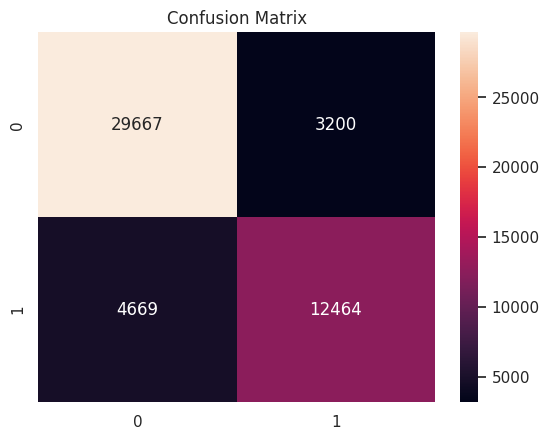

In [ ]:
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:,1]

print("Accuracy:", accuracy_score(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, y_pred))

sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

### 8.3 Cross-Validation

Cross-validation helps us check that our model’s performance is stable and not just lucky on one split.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
print("5-Fold Cross-Validated ROC AUC:", cv_auc.mean())

0:	total: 249ms	remaining: 4m 8s
100:	total: 7.81s	remaining: 1m 9s
200:	total: 16s	remaining: 1m 3s
300:	total: 24.5s	remaining: 56.9s
400:	total: 32s	remaining: 47.8s
500:	total: 40.7s	remaining: 40.5s
600:	total: 49.3s	remaining: 32.7s
700:	total: 56.8s	remaining: 24.2s
800:	total: 1m 5s	remaining: 16.2s
900:	total: 1m 14s	remaining: 8.15s
999:	total: 1m 21s	remaining: 0us
0:	total: 66.9ms	remaining: 1m 6s
100:	total: 8.84s	remaining: 1m 18s
200:	total: 16.9s	remaining: 1m 7s
300:	total: 25.2s	remaining: 58.6s
400:	total: 33.5s	remaining: 50.1s
500:	total: 41.9s	remaining: 41.7s
600:	total: 49.4s	remaining: 32.8s
700:	total: 57.7s	remaining: 24.6s
800:	total: 1m 6s	remaining: 16.5s
900:	total: 1m 13s	remaining: 8.11s
999:	total: 1m 22s	remaining: 0us
0:	total: 125ms	remaining: 2m 4s
100:	total: 8.64s	remaining: 1m 16s
200:	total: 15.9s	remaining: 1m 3s
300:	total: 24.3s	remaining: 56.4s
400:	total: 32.6s	remaining: 48.7s
500:	total: 39.9s	remaining: 39.7s
600:	total: 48.2s	remaining

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Placeholder for storing metrics if needed later
fold_reports = []

for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"--- Fold {fold+1}/{skf.n_splits} ---")

    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Create a new model instance for each fold to ensure independence
    fold_model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=8,
        eval_metric='AUC',
        verbose=0, # Reduce verbosity during CV
        random_seed=42
    )

    fold_model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold), use_best_model=True)

    # Get predictions for the validation fold
    y_pred_fold = fold_model.predict(X_val_fold)
    y_proba_fold = fold_model.predict_proba(X_val_fold)[:,1]

    # Print classification report for the current fold
    print(classification_report(y_val_fold, y_pred_fold))

    # Optionally store metrics
    fold_reports.append({
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val_fold, y_pred_fold),
        'roc_auc': roc_auc_score(y_val_fold, y_proba_fold),
        'classification_report': classification_report(y_val_fold, y_pred_fold, output_dict=True)
    })

    print("-" * 20)

# You can access the stored reports if needed
# for report in fold_reports:
#    print(f"Fold {report['fold']}: Accuracy = {report['accuracy']:.4f}, ROC AUC = {report['roc_auc']:.4f}")


--- Fold 1/5 ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     32866
           1       0.80      0.73      0.76     17134

    accuracy                           0.84     50000
   macro avg       0.83      0.82      0.82     50000
weighted avg       0.84      0.84      0.84     50000

--------------------
--- Fold 2/5 ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     32866
           1       0.79      0.73      0.76     17134

    accuracy                           0.84     50000
   macro avg       0.83      0.82      0.82     50000
weighted avg       0.84      0.84      0.84     50000

--------------------
--- Fold 3/5 ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88     32867
           1       0.80      0.73      0.76     17133

    accuracy                           0.84     50000
   macro avg       0.83      0.82  



## 9. Feature Importance

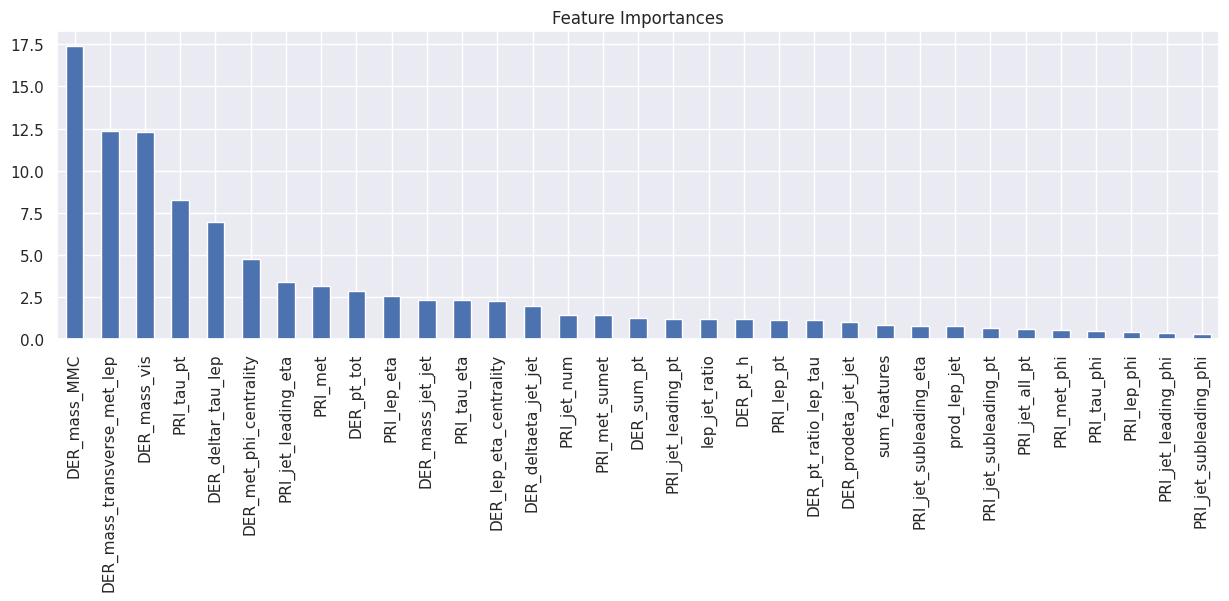

In [ ]:
importances = model.get_feature_importance()
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', figsize=(15,4), title='Feature Importances')
plt.show()


This chart shows which features the model thinks are most important. We can see which measurements help most in finding the Higgs boson.



## 10. Predictions on Test Set

In [ ]:
test_pred = model.predict_proba(test[features])[:,1]
prediction = pd.DataFrame({
    'EventId': test['EventId'],
    'Probability': test_pred
})
prediction.head()

,EventId,Probability
0,350000,0.004234
1,350001,0.069758
2,350002,0.501709
3,350003,0.879616
4,350004,0.012147


We use our trained model to predict the probability that each test event is a signal.

In [ ]:
# Evaluation
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Train ROC AUC:", roc_auc_score(y_train, y_proba_train))
print("\nTrain Classification Report:\n", classification_report(y_train, y_pred_train))

print("\nValidation Accuracy:", accuracy_score(y_val, y_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_proba))
print("\nValidation Classification Report:\n", classification_report(y_val, y_pred))

Train Accuracy: 0.858605
Train ROC AUC: 0.9274460797230054

Train Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89    131466
           1       0.82      0.75      0.78     68534

    accuracy                           0.86    200000
   macro avg       0.85      0.83      0.84    200000
weighted avg       0.86      0.86      0.86    200000


Validation Accuracy: 0.84262
Validation ROC AUC: 0.910929524783644

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88     32867
           1       0.80      0.73      0.76     17133

    accuracy                           0.84     50000
   macro avg       0.83      0.82      0.82     50000
weighted avg       0.84      0.84      0.84     50000



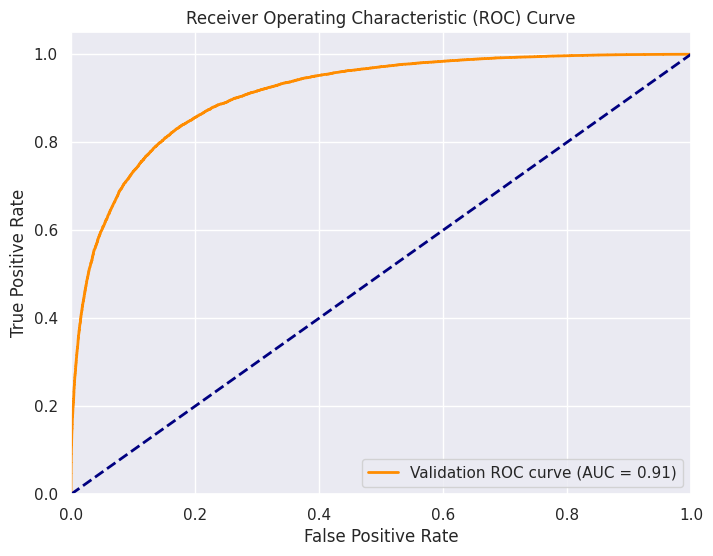

In [ ]:
#Plotting ROC - AUC curves for the validation and test data

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC for validation data
fpr_val, tpr_val, _ = roc_curve(y_val, y_proba)
roc_auc_val = auc(fpr_val, tpr_val)

# Plotting the ROC curve for the Validation set
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label=f'Validation ROC curve (AUC = {roc_auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## 11. Key Insights

- The data is imbalanced: more background than signal events.
- Some features (like DER_mass_MMC, DER_pt_h) are more useful in distinguishing signal from background.
- Feature engineering (adding sums, products, ratios) improved model performance.
- CatBoost achieved high ROC AUC, meaning it’s good at separating signal from background.
- Cross-validation shows our results are stable and reliable.



## 12. Conclusion


Explored the Higgs boson dataset, handled missing values, engineered new features, and built a powerful CatBoost model. This model can help physicists find rare Higgs boson events with high accuracy. The project demonstrates how data science can solve real-world scientific problems.



## 13. References

- [Kaggle Higgs Boson Challenge](https://www.kaggle.com/c/higgs-boson)
- CERN, ATLAS experiment documentation